Using TensorFlow backend.


(60000, 28, 28)


<Figure size 432x288 with 0 Axes>

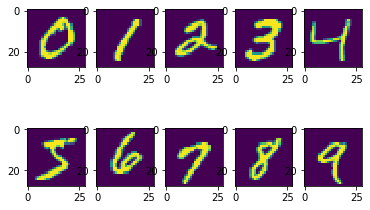

In [1]:
#代码示例：5-1
from keras.datasets import mnist
(X0,Y0),(X1,Y1) = mnist.load_data()
print(X0.shape)
from matplotlib import pyplot as plt
plt.figure()
fig,ax = plt.subplots(2,5)
ax=ax.flatten()
for i in range(10):
    Im=X0[Y0==i][0]
    ax[i].imshow(Im)
plt.show();

In [2]:
#代码示例：5-2
from keras.utils import np_utils
N0=X0.shape[0];N1=X1.shape[0]
print([N0,N1])
X0 = X0.reshape(N0,28,28,1)/255
X1 = X1.reshape(N1,28,28,1)/255
YY0 = np_utils.to_categorical(Y0)
YY1 = np_utils.to_categorical(Y1)
print(YY1)

[60000, 10000]
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [3]:
#代码示例：5-3
from keras.layers import Conv2D,Dense,Flatten,Input,MaxPooling2D 
from keras import Model

input_layer = Input([28,28,1])
x = input_layer
x = Conv2D(6,[5,5],padding = "same", activation = 'relu')(x) 
x = MaxPooling2D(pool_size = [2,2], strides = [2,2])(x)    
x = Conv2D(16,[5,5],padding = "valid", activation = 'relu')(x) 
x = MaxPooling2D(pool_size = [2,2], strides = [2,2])(x)
x = Flatten()(x)   
x = Dense(120,activation = 'relu')(x)
x = Dense(84,activation = 'relu')(x)
x = Dense(10,activation = 'softmax')(x)
output_layer=x
model=Model(input_layer,output_layer)
model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 28, 28, 1)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 6)         156       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 6)         0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 10, 10, 16)        2416      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 5, 5, 16)          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 400)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 120)               4812

In [4]:
#代码示例：5-4
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X0, YY0, epochs=10, batch_size=200, validation_data=[X1,YY1]) 

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 3s 51us/step - loss: 0.3388 - accuracy: 0.9011 - val_loss: 0.1024 - val_accuracy: 0.9683
Epoch 2/10
60000/60000 [==============================] - 1s 20us/step - loss: 0.0927 - accuracy: 0.9719 - val_loss: 0.0630 - val_accuracy: 0.9802
Epoch 3/10
60000/60000 [==============================] - 1s 20us/step - loss: 0.0674 - accuracy: 0.9797 - val_loss: 0.0510 - val_accuracy: 0.9843
Epoch 4/10
60000/60000 [==============================] - 1s 20us/step - loss: 0.0530 - accuracy: 0.9838 - val_loss: 0.0393 - val_accuracy: 0.9868
Epoch 5/10
60000/60000 [==============================] - 1s 20us/step - loss: 0.0438 - accuracy: 0.9865 - val_loss: 0.0328 - val_accuracy: 0.9888
Epoch 6/10
60000/60000 [==============================] - 1s 20us/step - loss: 0.0374 - accuracy: 0.9884 - val_loss: 0.0358 - val_accuracy: 0.9879
Epoch 7/10
60000/60000 [==============================] - 1s 21us/st

In [5]:
#代码示例：5-5
from keras.preprocessing.image import ImageDataGenerator

IMSIZE=227

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/ChineseStyle/test/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=200,
    class_mode='categorical')

train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/ChineseStyle/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=200,
    class_mode='categorical')

Found 5526 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.


<Figure size 432x288 with 0 Axes>

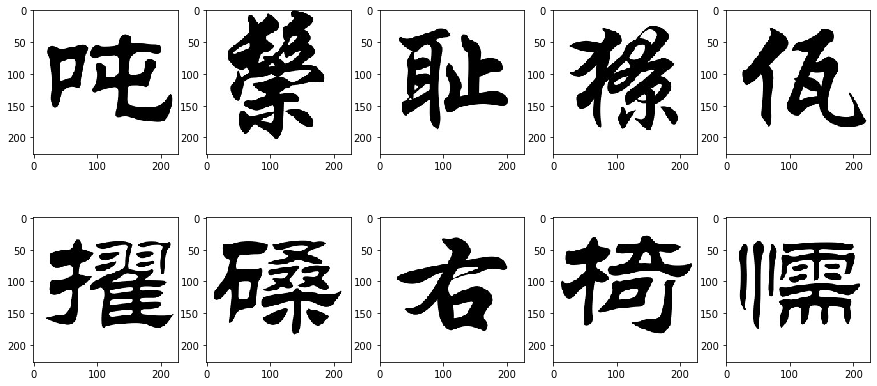

In [6]:
#代码示例：5-6
from matplotlib import pyplot as plt

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(7)
fig.set_figwidth(15)
ax=ax.flatten()
X,Y=next(validation_generator)
for i in range(10): ax[i].imshow(X[i,:,:,:])

In [7]:
#代码示例：5-7
from keras.layers import Activation,Conv2D, BatchNormalization, Dense
from keras.layers import Dropout, Flatten, Input, MaxPooling2D, ZeroPadding2D
from keras import Model

IMSIZE = 227
input_layer = Input([IMSIZE,IMSIZE,3])
x = input_layer
x = Conv2D(96,[11,11],strides = [4,4], activation = 'relu')(x) 
x = MaxPooling2D([3,3], strides = [2,2])(x)    
x = Conv2D(256,[5,5],padding = "same", activation = 'relu')(x)
x = MaxPooling2D([3,3], strides = [2,2])(x)
x = Conv2D(384,[3,3],padding = "same", activation = 'relu')(x) 
x = Conv2D(384,[3,3],padding = "same", activation = 'relu')(x) 
x = Conv2D(256,[3,3],padding = "same", activation = 'relu')(x) 
x = MaxPooling2D([3,3], strides = [2,2])(x)
x = Flatten()(x)   
x = Dense(4096,activation = 'relu')(x)
x = Dropout(0.5)(x)
x = Dense(4096,activation = 'relu')(x)
x = Dropout(0.5)(x)
x = Dense(2,activation = 'softmax')(x) 
output_layer=x
model=Model(input_layer,output_layer)
model.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 227, 227, 3)       0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 55, 55, 96)        34944     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 27, 27, 96)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 27, 27, 256)       614656    
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 13, 13, 256)       0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 13, 13, 384)       885120    
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 13, 13, 384)       1327

In [8]:
#代码示例：5-8
from keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),metrics=['accuracy'])
model.fit_generator(train_generator,epochs=5,validation_data=validation_generator)

Epoch 1/5
40/40 [==============================] - 33s 813ms/step - loss: 0.8585 - accuracy: 0.6122 - val_loss: 0.4312 - val_accuracy: 0.9130
Epoch 2/5
40/40 [==============================] - 28s 692ms/step - loss: 0.2435 - accuracy: 0.9106 - val_loss: 0.0563 - val_accuracy: 0.9797
Epoch 3/5
40/40 [==============================] - 29s 715ms/step - loss: 0.0409 - accuracy: 0.9871 - val_loss: 0.0015 - val_accuracy: 0.9937
Epoch 4/5
40/40 [==============================] - 28s 702ms/step - loss: 0.0174 - accuracy: 0.9951 - val_loss: 0.0024 - val_accuracy: 0.9962
Epoch 5/5
40/40 [==============================] - 28s 689ms/step - loss: 0.0104 - accuracy: 0.9971 - val_loss: 0.0114 - val_accuracy: 0.9967


In [1]:
#代码示例：5-9
from keras.preprocessing.image import ImageDataGenerator

IMSIZE = 224

train_generator = ImageDataGenerator(rescale=1. / 255).flow_from_directory(
    '/course7/data/data_vgg/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=32,
    class_mode='categorical')

validation_generator = ImageDataGenerator(
    rescale=1. / 255).flow_from_directory(
        '/course7/data/data_vgg/test',
        target_size=(IMSIZE, IMSIZE),
        batch_size=32,
        class_mode='categorical')

Using TensorFlow backend.


Found 8232 images belonging to 200 classes.
Found 3556 images belonging to 200 classes.


<Figure size 432x288 with 0 Axes>

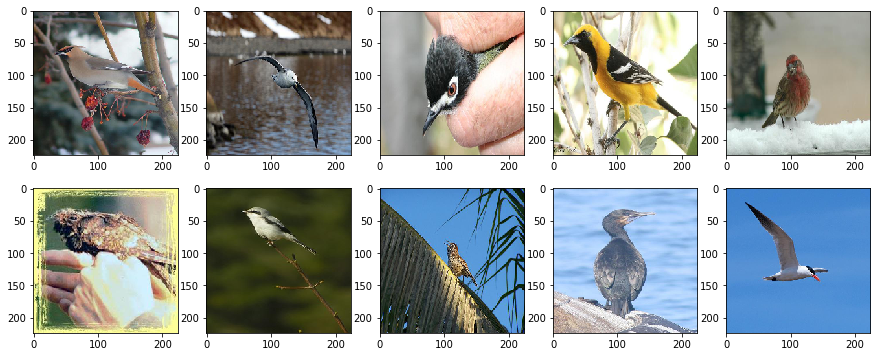

In [2]:
#代码示例：5-10
from matplotlib import pyplot as plt

plt.figure()
fig, ax = plt.subplots(2, 5)
fig.set_figheight(6)
fig.set_figwidth(15)
ax = ax.flatten()
X, Y = next(validation_generator)
for i in range(10):
    ax[i].imshow(X[i, :, :, ])

In [3]:
#代码示例：5-11(书稿的印刷中疏忽了全连接层)
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense, Input, Activation
from keras import Model
from keras.layers import GlobalAveragePooling2D

IMSIZE = 224
input_shape = (IMSIZE, IMSIZE, 3)
input_layer = Input(input_shape)
x = input_layer

x = Conv2D(64, [3, 3], padding='same', activation='relu')(x)
x = Conv2D(64, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, [3, 3], padding='same', activation='relu')(x)
x = Conv2D(128, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(256, [3, 3], padding='same', activation='relu')(x)
x = Conv2D(256, [3, 3], padding='same', activation='relu')(x)
x = Conv2D(256, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = Flatten()(x)
x = Dense(4096, activation = "relu")(x)
x = Dense(4096, activation = "relu")(x)
x = Dense(200, activation = "softmax")(x)
output_layer = x
model_vgg16 = Model(input_layer, output_layer)
model_vgg16.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 224, 224, 3)       0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 224, 224, 64)      1792      
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 224, 224, 64)      36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 112, 112, 64)      0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 112, 112, 128)     73856     
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 112, 112, 128)     147584    
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 56, 56, 128)       0   

In [4]:
#代码示例：5-12
from keras.optimizers import Adam
model_vgg16.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),metrics=['accuracy'])
model_vgg16.fit_generator(train_generator,epochs=5,validation_data=validation_generator)

Epoch 1/5
258/258 [==============================] - 117s 453ms/step - loss: 5.3009 - accuracy: 0.0032 - val_loss: 5.2934 - val_accuracy: 0.0051
Epoch 2/5
258/258 [==============================] - 83s 323ms/step - loss: 5.2991 - accuracy: 0.0028 - val_loss: 5.2936 - val_accuracy: 0.0051
Epoch 3/5
258/258 [==============================] - 85s 330ms/step - loss: 5.2989 - accuracy: 0.0027 - val_loss: 5.2949 - val_accuracy: 0.0051
Epoch 4/5
258/258 [==============================] - 90s 349ms/step - loss: 5.2987 - accuracy: 0.0035 - val_loss: 5.2929 - val_accuracy: 0.0051
Epoch 5/5
258/258 [==============================] - 83s 322ms/step - loss: 5.2986 - accuracy: 0.0026 - val_loss: 5.2978 - val_accuracy: 0.0051


In [2]:
#代码示例：5-13
from keras.layers import Conv2D, BatchNormalization, MaxPooling2D
from keras.layers import Flatten, Dense, Input, Activation
from keras import Model
from keras.layers import GlobalAveragePooling2D

IMSIZE = 224
input_shape = (IMSIZE, IMSIZE, 3)
input_layer = Input(input_shape)
x = input_layer

x = BatchNormalization(axis=3)(x)
x = Conv2D(64, [3, 3], padding='same', activation='relu')(x)
x = BatchNormalization(axis=3)(x)
x = Conv2D(64, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = BatchNormalization(axis=3)(x)
x = Conv2D(128, [3, 3], padding='same', activation='relu')(x)
x = BatchNormalization(axis=3)(x)
x = Conv2D(128, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = BatchNormalization(axis=3)(x)
x = Conv2D(256, [3, 3], padding='same', activation='relu')(x)
x = BatchNormalization(axis=3)(x)
x = Conv2D(256, [3, 3], padding='same', activation='relu')(x)
x = BatchNormalization(axis=3)(x)
x = Conv2D(256, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = BatchNormalization(axis=3)(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = BatchNormalization(axis=3)(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = BatchNormalization(axis=3)(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = BatchNormalization(axis=3)(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = BatchNormalization(axis=3)(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = BatchNormalization(axis=3)(x)
x = Conv2D(512, [3, 3], padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = Flatten()(x)
x = Dense(4096, activation = "relu")(x)
x = Dense(4096, activation = "relu")(x)
x = Dense(200, activation = "softmax")(x)
output_layer = x
model_vgg16_b = Model(input_layer, output_layer)
model_vgg16_b.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 224, 224, 3)       0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 224, 224, 3)       12        
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 224, 224, 64)      1792      
_________________________________________________________________
batch_normalization_2 (Batch (None, 224, 224, 64)      256       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 224, 224, 64)      36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 112, 112, 64)      0         
_________________________________________________________________
batch_normalization_3 (Batch (None, 112, 112, 64)      256 

In [3]:
#代码示例：5-14(作为示例，只跑3个epoch)
from keras.optimizers import Adam
model_vgg16_b.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.001),metrics=['accuracy'])
model_vgg16_b.fit_generator(train_generator,epochs=3,validation_data=validation_generator)

Epoch 1/3
258/258 [==============================] - 126s 488ms/step - loss: 8.0571 - accuracy: 0.0038 - val_loss: 5.3016 - val_accuracy: 0.0053
Epoch 2/3
258/258 [==============================] - 114s 442ms/step - loss: 5.3146 - accuracy: 0.0036 - val_loss: 5.3087 - val_accuracy: 0.0051
Epoch 3/3
258/258 [==============================] - 113s 440ms/step - loss: 5.2991 - accuracy: 0.0033 - val_loss: 5.3056 - val_accuracy: 0.0051


In [1]:
#代码示例：5-15
from keras.preprocessing.image import ImageDataGenerator

IMSIZE=128

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/CatDog/validation',
    target_size=(IMSIZE, IMSIZE),
    batch_size=200,
    class_mode='categorical')

train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/CatDog/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=200,
    class_mode='categorical')

Using TensorFlow backend.


Found 10000 images belonging to 2 classes.
Found 15000 images belonging to 2 classes.


In [2]:
#代码示例：5-16
import numpy as np
X,Y=next(validation_generator)
print(X.shape)
print(Y.shape)
Y[:,0]

(200, 128, 128, 3)
(200, 2)


array([1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1.,
       1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1.,
       0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0.,
       0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0.,
       0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0.,
       0., 1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1.,
       0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1.,
       0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0.], dtype=float32)

<Figure size 432x288 with 0 Axes>

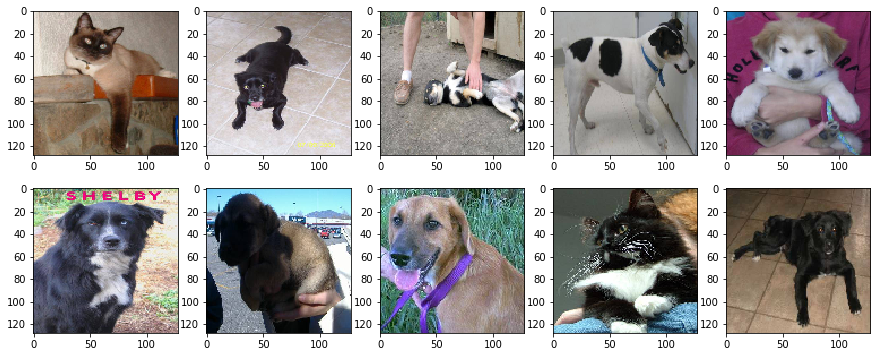

In [3]:
#代码示例：5-17
from matplotlib import pyplot as plt

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(6)
fig.set_figwidth(15)
ax=ax.flatten()
for i in range(10): ax[i].imshow(X[i,:,:,:])

In [4]:
#代码示例：5-18
from keras.layers import Flatten,Input,BatchNormalization,Dense
from keras import Model
input_layer=Input([IMSIZE,IMSIZE,3])
x=input_layer
x=BatchNormalization()(x)
x=Flatten()(x)
x=Dense(2,activation='softmax')(x)
output_layer=x
model1=Model(input_layer,output_layer)
model1.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 128, 128, 3)       0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 128, 128, 3)       12        
_________________________________________________________________
flatten_1 (Flatten)          (None, 49152)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 98306     
Total params: 98,318
Trainable params: 98,312
Non-trainable params: 6
_________________________________________________________________


In [5]:
#代码示例：5-19
#限于时间只运行5个epoch
from keras.optimizers import Adam
model1.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.01),metrics=['accuracy'])
model1.fit_generator(train_generator,epochs=5,validation_data=validation_generator)

Epoch 1/5
75/75 [==============================] - 198s 3s/step - loss: 15.8061 - accuracy: 0.5455 - val_loss: 1.9506 - val_accuracy: 0.5699
Epoch 2/5
75/75 [==============================] - 166s 2s/step - loss: 3.4117 - accuracy: 0.5898 - val_loss: 1.5365 - val_accuracy: 0.5564
Epoch 3/5
75/75 [==============================] - 176s 2s/step - loss: 1.5872 - accuracy: 0.6324 - val_loss: 0.9732 - val_accuracy: 0.5624
Epoch 4/5
75/75 [==============================] - 162s 2s/step - loss: 0.6609 - accuracy: 0.6867 - val_loss: 0.8186 - val_accuracy: 0.5482
Epoch 5/5
75/75 [==============================] - 169s 2s/step - loss: 0.5832 - accuracy: 0.7061 - val_loss: 0.6811 - val_accuracy: 0.5899


In [6]:
#代码示例：5-20
from keras.layers import Conv2D,MaxPooling2D

n_channel=100
input_layer=Input([IMSIZE,IMSIZE,3])
x=input_layer
x=BatchNormalization()(x)
x=Conv2D(n_channel,[2,2],activation='relu')(x)
x=MaxPooling2D([16,16])(x)
x=Flatten()(x)
x=Dense(2,activation='softmax')(x)
output_layer=x
model2=Model(input_layer,output_layer)
model2.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         (None, 128, 128, 3)       0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 128, 128, 3)       12        
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 127, 127, 100)     1300      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 7, 7, 100)         0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 4900)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 2)                 9802      
Total params: 11,114
Trainable params: 11,108
Non-trainable params: 6
_______________________________________________________

In [7]:
#代码示例：5-21
#限于时间只运行5个epoch
model2.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.01),metrics=['accuracy'])
model2.fit_generator(train_generator,epochs=5,validation_data=validation_generator)

Epoch 1/5
75/75 [==============================] - 176s 2s/step - loss: 1.1093 - accuracy: 0.6272 - val_loss: 0.6911 - val_accuracy: 0.5461
Epoch 2/5
75/75 [==============================] - 159s 2s/step - loss: 0.5229 - accuracy: 0.7382 - val_loss: 0.5790 - val_accuracy: 0.6775
Epoch 3/5
75/75 [==============================] - 158s 2s/step - loss: 0.4945 - accuracy: 0.7631 - val_loss: 0.5526 - val_accuracy: 0.7420
Epoch 4/5
75/75 [==============================] - 164s 2s/step - loss: 0.4934 - accuracy: 0.7658 - val_loss: 0.5092 - val_accuracy: 0.7467
Epoch 5/5
75/75 [==============================] - 186s 2s/step - loss: 0.4722 - accuracy: 0.7774 - val_loss: 0.4859 - val_accuracy: 0.7853


In [8]:
#代码示例：5-22
n_channel=20
input_layer=Input([IMSIZE,IMSIZE,3])
x=input_layer
x=BatchNormalization()(x)
for _ in range(7):
    x=Conv2D(n_channel,[2,2],padding='same',activation='relu')(x)
    x=MaxPooling2D([2,2])(x)
x=Flatten()(x)
x=Dense(2,activation='softmax')(x)
output_layer=x
model3=Model(input_layer,output_layer)
model3.summary()

Model: "model_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         (None, 128, 128, 3)       0         
_________________________________________________________________
batch_normalization_3 (Batch (None, 128, 128, 3)       12        
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 128, 128, 20)      260       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 64, 64, 20)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 64, 64, 20)        1620      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 32, 32, 20)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 32, 32, 20)        1620

In [9]:
#代码示例：5-23
#限于时间只运行5个epoch
model3.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.01),metrics=['accuracy'])
model3.fit_generator(train_generator,epochs=5,validation_data=validation_generator)

Epoch 1/5
75/75 [==============================] - 173s 2s/step - loss: 0.6701 - accuracy: 0.5757 - val_loss: 0.6780 - val_accuracy: 0.5613
Epoch 2/5
75/75 [==============================] - 165s 2s/step - loss: 0.6182 - accuracy: 0.6486 - val_loss: 0.6700 - val_accuracy: 0.6068
Epoch 3/5
75/75 [==============================] - 163s 2s/step - loss: 0.5942 - accuracy: 0.6797 - val_loss: 0.5193 - val_accuracy: 0.6970
Epoch 4/5
75/75 [==============================] - 165s 2s/step - loss: 0.5379 - accuracy: 0.7305 - val_loss: 0.4793 - val_accuracy: 0.7337
Epoch 5/5
75/75 [==============================] - 167s 2s/step - loss: 0.5134 - accuracy: 0.7442 - val_loss: 0.4685 - val_accuracy: 0.7470


In [1]:
#代码示例：5-24
from keras.preprocessing.image import ImageDataGenerator

IMSIZE=128

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/course7/data/CatDog/validation',
    target_size=(IMSIZE, IMSIZE),
    batch_size=200,
    class_mode='categorical')

Using TensorFlow backend.


Found 10000 images belonging to 2 classes.


In [2]:
#代码示例：5-25
train_generator = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.5,
    rotation_range=30,
    zoom_range=0.2, 
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True).flow_from_directory(
    '/course7/data/CatDog/train',
    target_size=(IMSIZE, IMSIZE),
    batch_size=200,
    class_mode='categorical')

Found 15000 images belonging to 2 classes.


<Figure size 432x288 with 0 Axes>

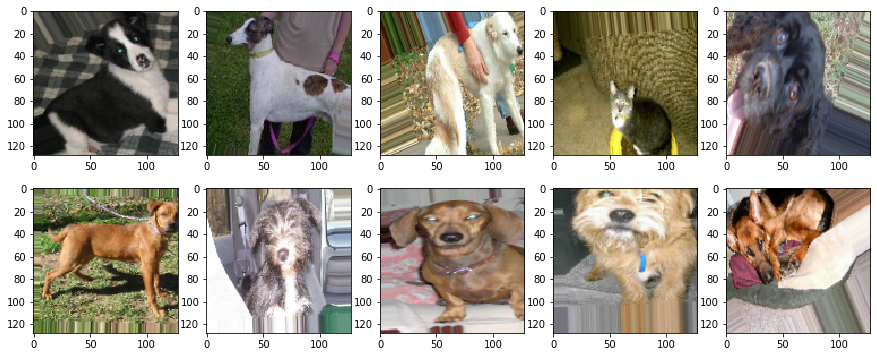

In [3]:
#代码示例：5-26
from matplotlib import pyplot as plt

plt.figure()
fig,ax = plt.subplots(2,5)
fig.set_figheight(6)
fig.set_figwidth(15)
ax=ax.flatten()
X,Y=next(train_generator)
for i in range(10): ax[i].imshow(X[i,:,:,:])

In [4]:
#代码示例：5-27
IMSIZE=128
from keras.layers import BatchNormalization,Conv2D,Dense,Flatten,Input,MaxPooling2D
from keras import Model

n_channel=100
input_layer=Input([IMSIZE,IMSIZE,3])
x=input_layer
x=BatchNormalization()(x)
for _ in range(7):
    x=BatchNormalization()(x)
    x=Conv2D(n_channel,[2,2],padding='same',activation='relu')(x)
    x=MaxPooling2D([2,2])(x)

x=Flatten()(x)
x=Dense(2,activation='softmax')(x)
output_layer=x
model=Model(input_layer,output_layer)
model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 128, 128, 3)       0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 128, 128, 3)       12        
_________________________________________________________________
batch_normalization_2 (Batch (None, 128, 128, 3)       12        
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 128, 128, 100)     1300      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 64, 64, 100)       0         
_________________________________________________________________
batch_normalization_3 (Batch (None, 64, 64, 100)       400       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 64, 64, 100)       4010

In [5]:
#代码示例：5-28
#限于时间只运行5个epoch
from keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',optimizer=Adam(lr=0.0001),metrics=['accuracy'])
model.fit_generator(train_generator,epochs=5,validation_data=validation_generator)

Epoch 1/5
75/75 [==============================] - 248s 3s/step - loss: 0.6689 - accuracy: 0.6155 - val_loss: 0.6910 - val_accuracy: 0.5373
Epoch 2/5
75/75 [==============================] - 228s 3s/step - loss: 0.6139 - accuracy: 0.6631 - val_loss: 0.6925 - val_accuracy: 0.5433
Epoch 3/5
75/75 [==============================] - 218s 3s/step - loss: 0.5815 - accuracy: 0.6923 - val_loss: 0.6852 - val_accuracy: 0.5794
Epoch 4/5
75/75 [==============================] - 222s 3s/step - loss: 0.5647 - accuracy: 0.7016 - val_loss: 0.6374 - val_accuracy: 0.5992
Epoch 5/5
75/75 [==============================] - 245s 3s/step - loss: 0.5498 - accuracy: 0.7154 - val_loss: 0.7033 - val_accuracy: 0.6037
